# Support Vector Classifier

Support-vector machines (SVMs) are supervised learning models used for classification and regression, known for its kernel trick to handle nonlinear input spaces. This template builds, trains, and tunes an SVM for a **classification** problem. If you would like to learn more about SVMs, take a look at DataCamp's [Linear Classifiers in Python]( https://app.datacamp.com/learn/courses/linear-classifiers-in-python ) course.

To swap in your dataset in this template, the following is required:
- There must be at least one feature column and a column with a categorical target variable you would like to predict.
- The features have been cleaned and preprocessed, including categorical encoding.
- There are no NaN/NA values. You can use [this template to impute missing values](https://app.datacamp.com/workspace/templates/recipe-python-impute-missing-data) if needed.

The placeholder dataset in this template consists of hotel booking data with details, such as length of stay. Each row represents a booking and whether the booking was canceled (the target variable). You can find more information on this dataset's source and dictionary [here]( https://app.datacamp.com/workspace/datasets/dataset-python-hotel-booking-demand  ).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    RocCurveDisplay,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd 
df = pd.read_csv("../data/hotel_bookings_clean.csv")
print(df.sample(7).T)

                                727    1217    527   1195   1487  1289   241 
is_canceled                      1.0    1.0    0.00   1.0    0.0   0.0    0.0
lead_time                      221.0  461.0   72.00  99.0    3.0  30.0  343.0
arrival_date_week_number        24.0   42.0   33.00   8.0   18.0  38.0   39.0
stays_in_weekend_nights          1.0    0.0    0.00   0.0    2.0   1.0    0.0
stays_in_week_nights             2.0    2.0    2.00   1.0    3.0   3.0    4.0
adults                           2.0    2.0    2.00   2.0    1.0   2.0    2.0
is_repeated_guest                0.0    0.0    0.00   0.0    0.0   0.0    0.0
previous_cancellations           1.0    0.0    0.00   1.0    0.0   0.0    0.0
total_of_special_requests        0.0    0.0    0.00   0.0    1.0   2.0    0.0
avg_daily_rate                  80.0   62.0  207.05  80.0  116.0  94.5   92.0
booked_by_company                0.0    0.0    0.00   1.0    0.0   0.0    0.0
booked_by_agent                  1.0    1.0    1.00   0.0    1.0

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   is_canceled                    1500 non-null   int64  
 1   lead_time                      1500 non-null   int64  
 2   arrival_date_week_number       1500 non-null   int64  
 3   stays_in_weekend_nights        1500 non-null   int64  
 4   stays_in_week_nights           1500 non-null   int64  
 5   adults                         1500 non-null   int64  
 6   is_repeated_guest              1500 non-null   int64  
 7   previous_cancellations         1500 non-null   int64  
 8   total_of_special_requests      1500 non-null   int64  
 9   avg_daily_rate                 1500 non-null   float64
 10  booked_by_company              1500 non-null   int64  
 11  booked_by_agent                1500 non-null   int64  
 12  customer_type_Contract         1500 non-null   i

In [5]:
print(df.shape)

(1500, 16)


In [6]:
print(df.isna().sum())

is_canceled                      0
lead_time                        0
arrival_date_week_number         0
stays_in_weekend_nights          0
stays_in_week_nights             0
adults                           0
is_repeated_guest                0
previous_cancellations           0
total_of_special_requests        0
avg_daily_rate                   0
booked_by_company                0
booked_by_agent                  0
customer_type_Contract           0
customer_type_Group              0
customer_type_Transient          0
customer_type_Transient-Party    0
dtype: int64


In [7]:
import numpy as np
print(f'Duplicates in this df: {df.duplicated().sum()}, ({np.round(100*df.duplicated().sum()/len(df),1)}%)')

Duplicates in this df: 52, (3.5%)


In [8]:
df["is_canceled"].value_counts()

is_canceled
0    951
1    549
Name: count, dtype: int64

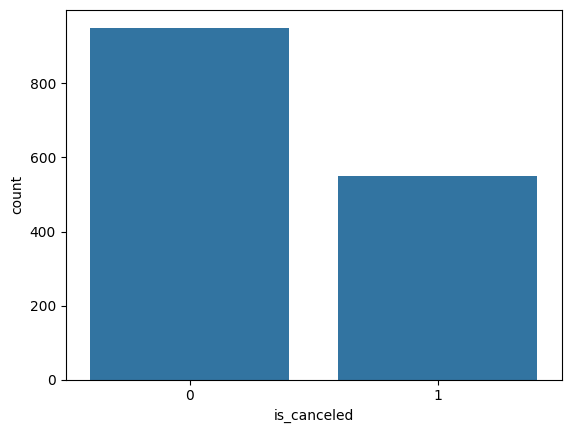

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x= df['is_canceled'])
plt.show()

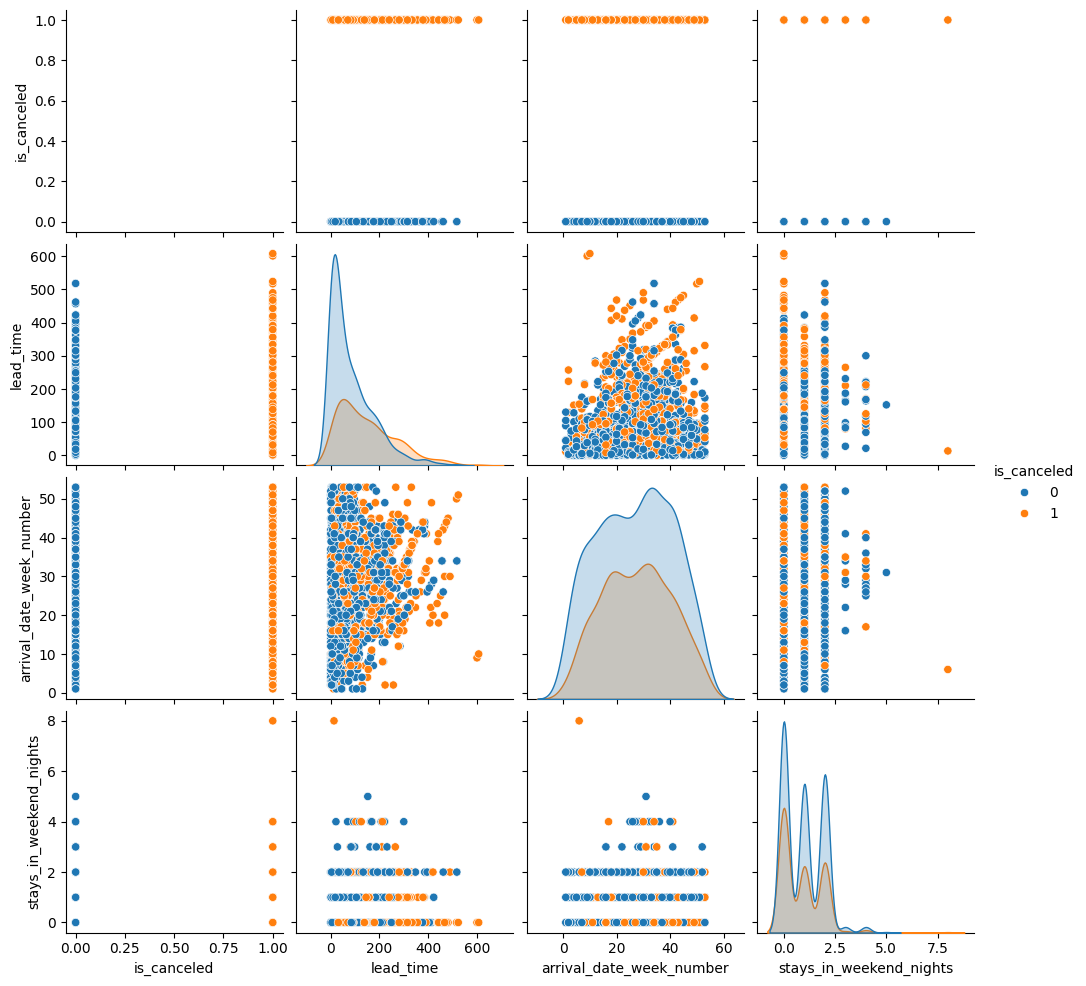

In [10]:
sns.pairplot(df, vars=df.columns[0:4], hue="is_canceled")

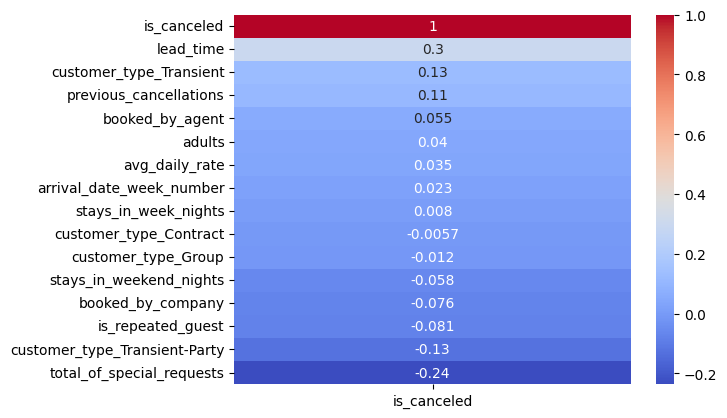

In [11]:
sns.heatmap(df.corr(numeric_only=True)["is_canceled"].sort_values(ascending=False).to_frame(), cmap="coolwarm", annot=True)
plt.show()

<Axes: >

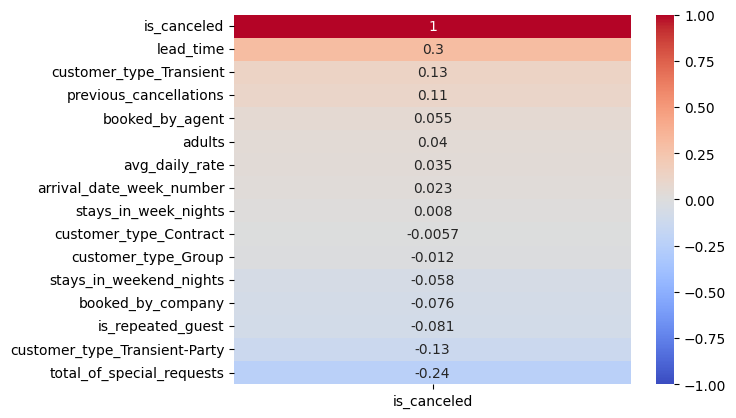

In [12]:
# OPLETTEN voor de kleuren: best van -1 tot 1 nemen:
sns.heatmap(df.corr(numeric_only=True)["is_canceled"].sort_values(ascending=False).to_frame(), cmap="coolwarm", annot=True, vmin=-1, vmax=1)

In [13]:
# Split the data into two DataFrames: X (features) and y (target variable)
X = df.iloc[:, 1:]  # Specify at least one column as feature(s)
y = df["is_canceled"]  # Specify one column as the target variable

# Split the data into train and test subsets
# You can adjust the test size and random state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1050, 15), (450, 15), (1050,), (450,))

In [14]:
# Define a parameter grid with distributions of possible parameters to use
rs_param_grid = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "C": [0.1, 1, 10],
    "gamma": [0.00001, 0.0001, 0.001, 0.01, 0.1],
}
clf = svm.SVC(random_state=123)

In [ ]:
# RandomizedSearch die zoekt de beste params (combinaties, i.e. cv*n_iter) binnen door ons gedefinieerde grid:
# Hier is 3*10 = 30 mogelijke combinaties, duurt lang > 18 min and counting (interrupted)

clf_rs = RandomizedSearchCV(
    estimator= clf,
    param_distributions=rs_param_grid,
    cv=3,
    n_iter=10,
    random_state=123
)
clf_rs.fit(X_train,y_train)